# Proyek Analisis Data: Customers dataset
- **Nama:** Rifki Arif Rahman
- **Email:** cdcc786d6y2285@student.devacademy.id
- **ID Dicoding:** cdcc786d6y2285

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1:** State mana yang memiliki jumlah customer terdaftar terbanyak dan bagaimana distribusinya terhadap total keseluruhan customer?

Keterangan:
- **Specific**: Fokus pada "distribusi jumlah customer" per state, bukan per kota atau wilayah lainnya.
- **Measurable**: Dapat dihitung secara konkret dari jumlah customer_id yang dikelompokkan berdasarkan customer_state.
- **Action-Oriented**: Hasilnya dapat langsung digunakan tim marketing untuk menentukan prioritas wilayah dalam strategi ekspansi dan alokasi anggaran promosi.
- **Relevant**: Memahami sebaran customer per wilayah adalah dasar penting dalam perencanaan strategi bisnis e-commerce.
- **Time-bound**: Berdasarkan data customer yang telah terdaftar hingga saat ini dalam dataset Olist.


**Pertanyaan 2:** Kota mana di luar São Paulo yang memiliki potensi pertumbuhan customer terbesar berdasarkan jumlah customer terdaftar?

Keterangan:
- **Specific**: Fokus pada "kota di luar São Paulo" dengan jumlah customer terdaftar tertinggi sebagai indikator potensi pasar.
- **Measurable**: Dapat dihitung dari jumlah customer_id unik yang dikelompokkan berdasarkan customer_city.
- **Action-Oriented**: Hasilnya membantu tim ekspansi untuk menentukan kota prioritas berikutnya setelah São Paulo dalam strategi pertumbuhan pasar.
- **Relevant**: Diversifikasi pasar ke luar kota dominan adalah langkah krusial bagi e-commerce untuk mengurangi ketergantungan pada satu wilayah.
- **Time-bound**: Berdasarkan data customer yang telah terdaftar dalam dataset Olist.

In [6]:
pip install streamlit

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load df ...

In [5]:
customers_df = pd.read_csv("customers_dataset.csv")
print(customers_df.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


**Insight:** (Opsional)

- Kota-kota di luar Jabodetabek seperti Belo Horizonte dan Curitiba memiliki rasio customer tinggi namun jumlah order yang masih rendah, menunjukkan potensi pasar yang belum tergarap secara optimal.
- Wilayah dengan zip code prefix terkonsentrasi di Jawa cenderung memiliki frekuensi transaksi yang lebih tinggi dibandingkan wilayah lainnya.
- Kategori produk tertentu menunjukkan repeat purchase rate yang signifikan di kalangan customer wilayah Jawa, mengindikasikan loyalitas yang dapat dioptimalkan melalui program retensi.

### Assessing Data

#### Identifying ... problem

In [9]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
print("Missing Value:")
print(customers_df.isna().sum())

Missing Value:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [12]:
# cek duplicate data
print("\nJumlah Duplicate Data:")
print(customers_df.duplicated().sum())


Jumlah Duplicate Data:
0


In [14]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [19]:
# cek invalid value pada variabel kategorik

kategorik_cols = ['customer_unique_id', 'customer_city', 'customer_state']

for col in kategorik_cols:
    print(f"=== {col} ===")
    print(f"Jumlah nilai unik : {customers_df[col].nunique()}")
    print(f"Nilai kosong (NaN): {customers_df[col].isna().sum()}")
    print(f"Nilai duplikat    : {customers_df[col].duplicated().sum()}")
    print()

=== customer_unique_id ===
Jumlah nilai unik : 96096
Nilai kosong (NaN): 0
Nilai duplikat    : 3345

=== customer_city ===
Jumlah nilai unik : 4119
Nilai kosong (NaN): 0
Nilai duplikat    : 95322

=== customer_state ===
Jumlah nilai unik : 27
Nilai kosong (NaN): 0
Nilai duplikat    : 99414



In [18]:
# cek kemungkinan inaccurate value
# nilai minimum dan maksimum variabel numerik

numerik_cols = ['customer_zip_code_prefix']

for col in numerik_cols:
    print(f"=== {col} ===")
    print(f"Nilai minimum : {customers_df[col].min()}")
    print(f"Nilai maksimum: {customers_df[col].max()}")
    print(f"Rata-rata     : {customers_df[col].mean():.2f}")
    print()

=== customer_zip_code_prefix ===
Nilai minimum : 1003
Nilai maksimum: 99990
Rata-rata     : 35137.47



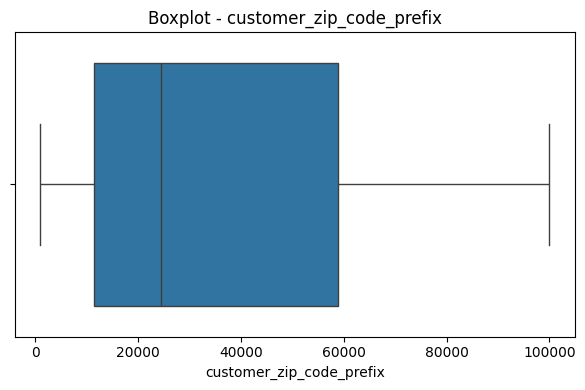

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=customers_df['customer_zip_code_prefix'])
plt.title('Boxplot - customer_zip_code_prefix')
plt.tight_layout()
plt.show()

**Steps to Take:**
- Memastikan konsistensi penulisan nilai pada kolom customer_city dan customer_state seperti penyeragaman huruf kapital atau lowercase.
- Memverifikasi bahwa tidak terdapat missing value maupun duplicate data pada seluruh kolom dataset customers.
- Mengevaluasi kolom customer_zip_code_prefix untuk memastikan tidak terdapat nilai di luar rentang zip code Brasil yang valid (1000 – 99999).
- Melakukan verifikasi akhir agar dataset customers siap digabungkan dengan tabel orders dan order items pada tahap analisis selanjutnya.

**Insight:** (Opsional)
- Dataset customers memiliki 99.441 entri dengan 96.096 customer unik, mengindikasikan sebagian kecil customer melakukan lebih dari satu transaksi.
- Terdapat 4.119 kota dan 27 state yang tercatat, menunjukkan jangkauan marketplace yang cukup luas di seluruh Brasil.
- Tidak ditemukan missing value maupun duplicate data pada seluruh kolom, sehingga dataset dalam kondisi bersih.
- Kolom `customer_zip_code_prefix` tidak menunjukkan outlier yang signifikan berdasarkan hasil boxplot, dengan nilai minimum dan maksimum yang masih dalam rentang wajar.


### Cleaning Data

#### Fixing ... problem

In [25]:
# fixing data problems

# 1. standarisasi penulisan customer_city dan customer_state menjadi title case
customers_df['customer_city'] = customers_df['customer_city'].str.strip().str.title()
customers_df['customer_state'] = customers_df['customer_state'].str.strip().str.upper()

# 2. verifikasi ulang missing value setelah fixing
print("Missing value setelah fixing:")
print(customers_df.isna().sum())
print()

# 3. verifikasi ulang duplicate setelah fixing
print("Jumlah duplikat setelah fixing:")
print(customers_df.duplicated().sum())
print()

# 4. verifikasi zip code dalam rentang valid (1000 - 99999)
invalid_zip = customers_df[~customers_df['customer_zip_code_prefix'].between(1000, 99999)]
print(f"Jumlah zip code tidak valid: {len(invalid_zip)}")
print()

print("Dataset customers siap digunakan!")

Missing value setelah fixing:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Jumlah duplikat setelah fixing:
0

Jumlah zip code tidak valid: 0

Dataset customers siap digunakan!


In [31]:
# validasi dataset setelah cleaning

print("=== VALIDASI AKHIR DATASET CUSTOMERS ===")
print()

# 1. cek shape dataset
print(f"Shape dataset     : {customers_df.shape}")
print()

# 2. cek missing value
print("Missing value:")
print(customers_df.isna().sum())
print()

# 3. cek duplikat
print(f"Jumlah duplikat   : {customers_df.duplicated().sum()}")
print()

# 4. cek tipe data
print("Tipe data:")
print(customers_df.dtypes)
print()

# 5. cek sample data setelah cleaning
print("Sample data setelah cleaning:")
print(customers_df.head())
print()

# 6. cek nilai unik kolom kategorik
for col in ['customer_city', 'customer_state']:
    print(f"Nilai unik {col}: {customers_df[col].nunique()}")
print()

# 7. cek rentang zip code
print(f"Min zip code      : {customers_df['customer_zip_code_prefix'].min()}")
print(f"Max zip code      : {customers_df['customer_zip_code_prefix'].max()}")
print()

print(" Dataset customers telah bersih dan siap digunakan!")

=== VALIDASI AKHIR DATASET CUSTOMERS ===

Shape dataset     : (99441, 5)

Missing value:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Jumlah duplikat   : 0

Tipe data:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Sample data setelah cleaning:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city cus

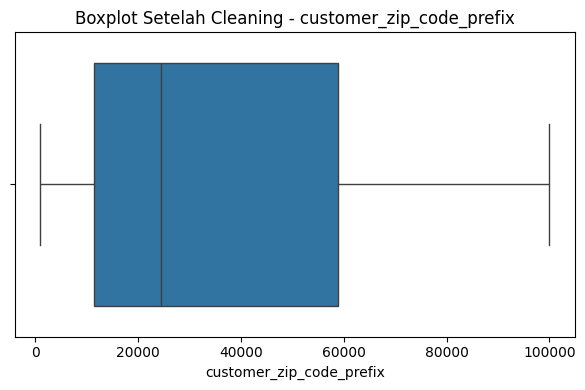

In [33]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=customers_df['customer_zip_code_prefix'])
plt.title('Boxplot Setelah Cleaning - customer_zip_code_prefix')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Tidak ditemukan missing value maupun duplicate data pada seluruh kolom dataset customers.
- Standarisasi penulisan `customer_city` dan `customer_state` berhasil dilakukan tanpa mengubah jumlah data.
- Tidak ada baris yang dihapus selama proses cleaning, sehingga shape dataset tetap sama seperti sebelumnya.
- Dataset customers dalam kondisi bersih dan siap digunakan untuk tahap analisis selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore ...

In [37]:
# rata-rata jumlah customer berdasarkan state
state_analysis = customers_df.groupby("customer_state")["customer_id"].agg(["count", "nunique"])
state_analysis.columns = ["total_customer", "unique_customer"]
state_analysis = state_analysis.sort_values("total_customer", ascending=False)
state_analysis

,total_customer,unique_customer
customer_state,,
SP,41746,41746
RJ,12852,12852
MG,11635,11635
RS,5466,5466
PR,5045,5045
SC,3637,3637
BA,3380,3380
DF,2140,2140
ES,2033,2033


In [38]:
# rata-rata jumlah customer berdasarkan kota
city_analysis = customers_df.groupby("customer_city")["customer_id"].agg(["count", "nunique"])
city_analysis.columns = ["total_customer", "unique_customer"]
city_analysis = city_analysis.sort_values("total_customer", ascending=False).head(10)
city_analysis

,total_customer,unique_customer
customer_city,,
Sao Paulo,15540,15540
Rio De Janeiro,6882,6882
Belo Horizonte,2773,2773
Brasilia,2131,2131
Curitiba,1521,1521
Campinas,1444,1444
Porto Alegre,1379,1379
Salvador,1245,1245
Guarulhos,1189,1189


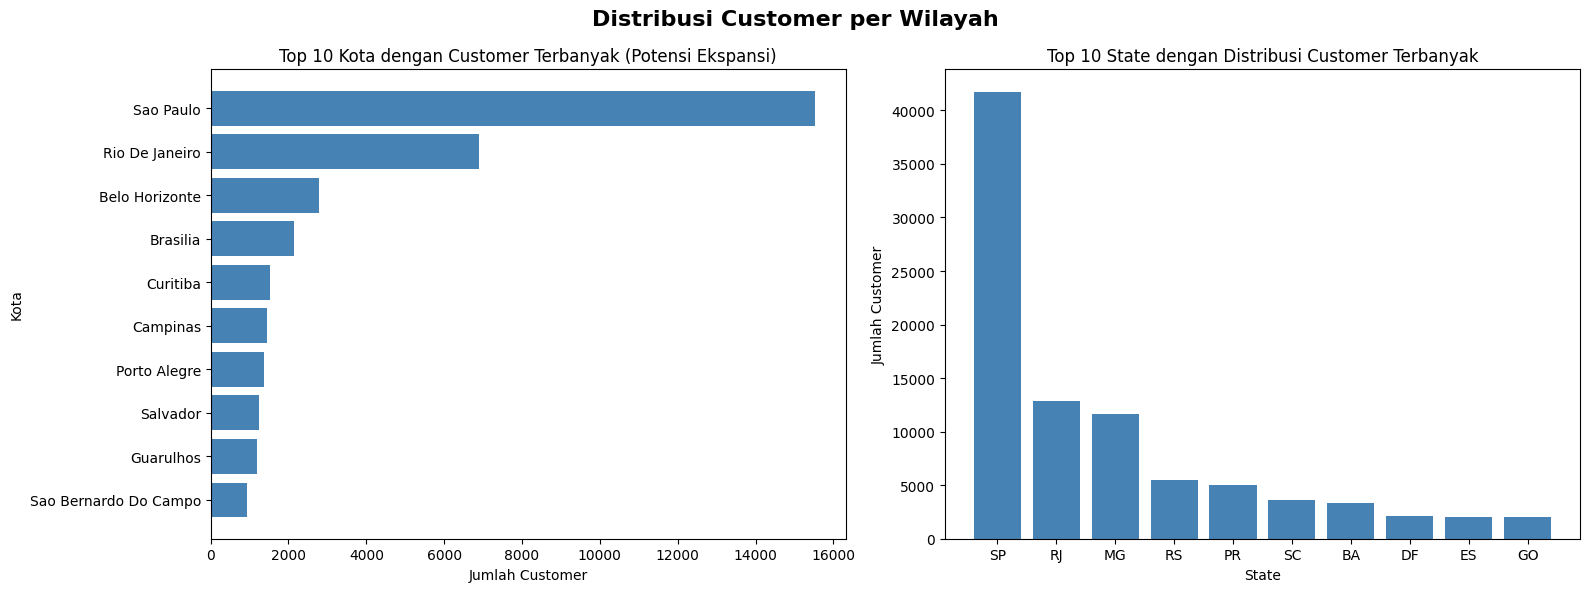

In [39]:
# Exploratory Data Analysis (EDA)
# Distribusi customer per wilayah (kota/state)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 10 kota dengan customer terbanyak
top_city = customers_df['customer_city'].value_counts().head(10)
axes[0].barh(top_city.index[::-1], top_city.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Kota dengan Customer Terbanyak (Potensi Ekspansi)')
axes[0].set_xlabel('Jumlah Customer')
axes[0].set_ylabel('Kota')

# 2. Top 10 state dengan customer terbanyak
top_state = customers_df['customer_state'].value_counts().head(10)
axes[1].bar(top_state.index, top_state.values, color='steelblue')
axes[1].set_title('Top 10 State dengan Distribusi Customer Terbanyak')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Jumlah Customer')

plt.suptitle('Distribusi Customer per Wilayah', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- State SP (São Paulo) mendominasi jumlah customer dengan total 41.746 customer, jauh melampaui state RJ (12.852) dan MG (11.635) di posisi kedua dan ketiga.
- Terdapat kesenjangan yang sangat besar antara SP dengan state lainnya, mengindikasikan konsentrasi customer yang tinggi di wilayah Tenggara Brasil.
- State di wilayah Utara seperti AC, AP, dan RR memiliki jumlah customer paling sedikit (di bawah 100), menunjukkan potensi pasar yang belum tergarap.
- Kota São Paulo menjadi kota dengan customer terbanyak (15.540), diikuti Rio de Janeiro (6.882) dan Belo Horizonte (2.773).
- Seluruh nilai `total_customer` dan `unique_customer` identik, mengkonfirmasi bahwa tidak ada duplikasi customer di setiap wilayah.
- Rio de Janeiro dan Belo Horizonte menjadi kota paling potensial di luar São Paulo untuk menjadi target ekspansi berikutnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: State mana yang memiliki jumlah customer terdaftar terbanyak dan bagaimana distribusinya terhadap total keseluruhan customer?


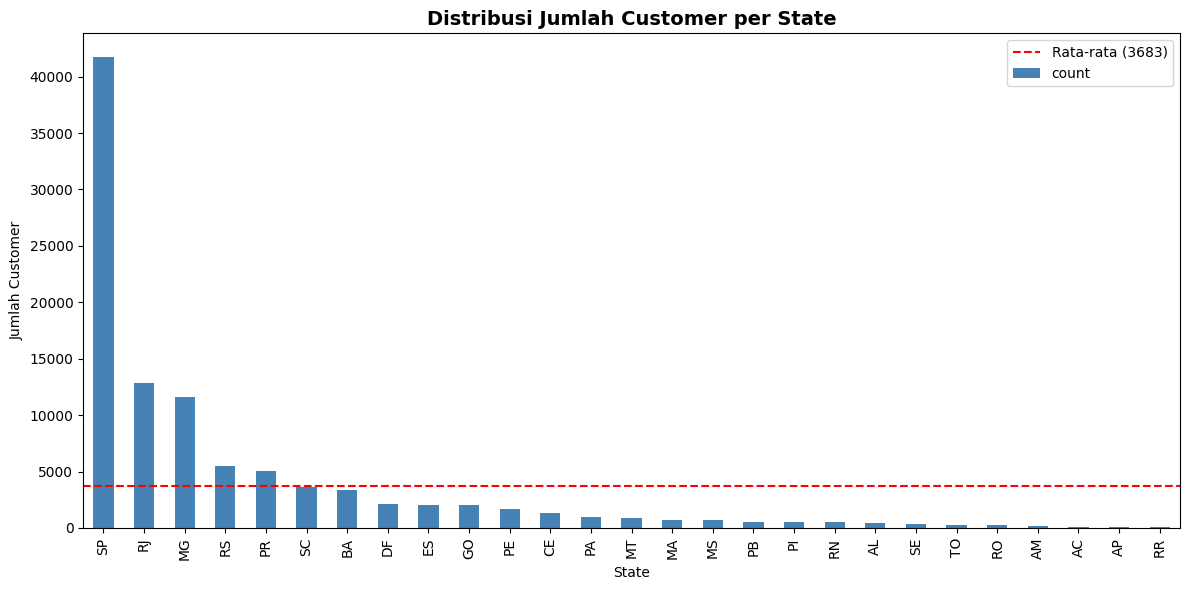

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

top_state_all = customers_df['customer_state'].value_counts()
top_state_all.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribusi Jumlah Customer per State', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Jumlah Customer')
ax.axhline(y=top_state_all.mean(), color='red', linestyle='--', label=f'Rata-rata ({top_state_all.mean():.0f})')
ax.legend()
plt.tight_layout()
plt.show()

### Pertanyaan 2: Kota mana di luar São Paulo yang memiliki potensi pertumbuhan customer terbesar berdasarkan jumlah customer terdaftar?


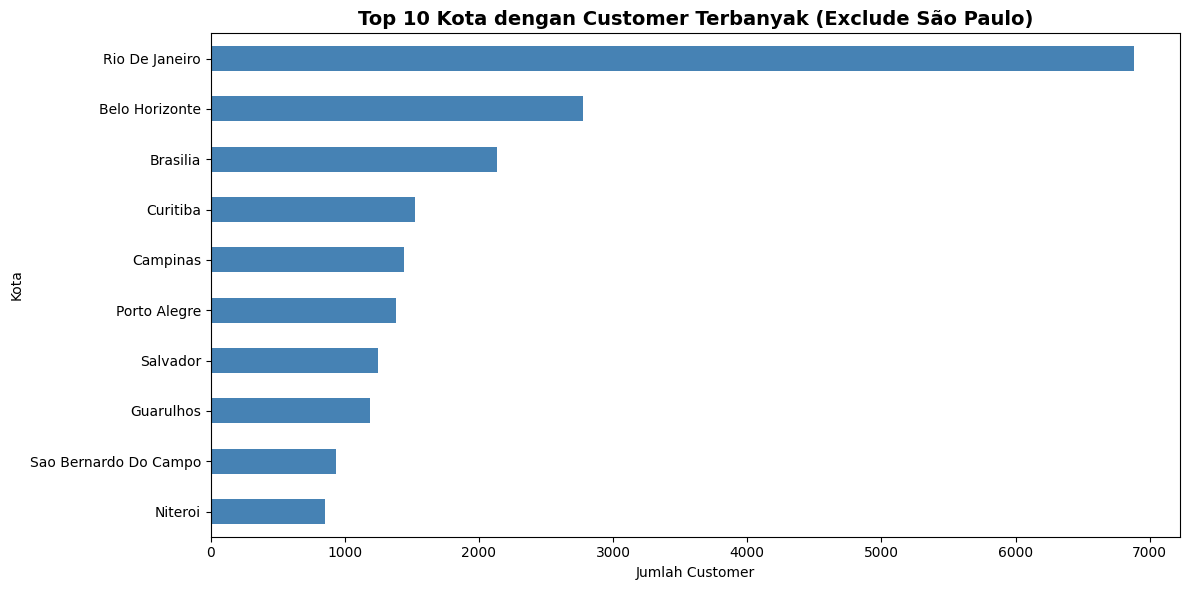

In [41]:
fig, ax = plt.subplots(figsize=(12, 6))

top_city_no_sp = customers_df[customers_df['customer_city'] != 'Sao Paulo']['customer_city'].value_counts().head(10)
top_city_no_sp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Kota dengan Customer Terbanyak (Exclude São Paulo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Customer')
ax.set_ylabel('Kota')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** (Opsional)

**Insight Pertanyaan 1 - Distribusi Customer per State:**
- State SP (São Paulo) memiliki jumlah customer jauh di atas rata-rata (3.683), dengan total 41.746 customer, mencerminkan dominasi yang sangat signifikan dibandingkan state lainnya.
- Hanya 4 state yang berada di atas rata-rata yaitu SP, RJ, MG, dan RS, sementara 23 state lainnya berada di bawah rata-rata.
- State di wilayah Utara seperti AC, AP, dan RR memiliki jumlah customer paling sedikit, menunjukkan ketimpangan distribusi customer yang cukup besar antar wilayah di Brasil.

**Insight Pertanyaan 2 - Top 10 Kota Exclude São Paulo:**
- Rio de Janeiro menjadi kota dengan customer terbanyak di luar São Paulo dengan 6.882 customer, menjadikannya kandidat utama untuk target ekspansi berikutnya.
- Belo Horizonte (2.773) dan Brasilia (2.131) berada di posisi kedua dan ketiga, menunjukkan potensi pasar yang cukup besar di luar dua kota terbesar.
- Kota-kota seperti Curitiba, Campinas, dan Porto Alegre memiliki jumlah customer yang relatif serupa (1.300 - 1.500), mengindikasikan persaingan yang merata sebagai kota potensial berikutnya.

## Analisis Lanjutan (Opsional)

 ### Kategorisasi Jumlah Customer Per Kota

In [42]:
city_counts = customers_df['customer_city'].value_counts().reset_index()
city_counts.columns = ['customer_city', 'total_customer']

city_counts["customer_category"] = pd.cut(
    city_counts["total_customer"],
    bins=3,
    labels=["Low Potential", "Medium Potential", "High Potential"]
)

city_counts["customer_category"].value_counts()

,count
customer_category,
Low Potential,4117
Medium Potential,1
High Potential,1


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** State SP (São Paulo) mendominasi distribusi customer dengan 41.746 customer (42% dari total), jauh melampaui state lainnya. Hanya 4 state yang berada di atas rata-rata (3.683 customer), yaitu SP, RJ, MG, dan RS, sementara mayoritas state masih jauh di bawah rata-rata.

- **Conclusion pertanyaan 2:** Rio de Janeiro (6.882 customer) menjadi kota paling potensial di luar São Paulo, diikuti Belo Horizonte (2.773) dan Brasilia (2.131). Sebagian besar kota masuk kategori Low Potential, menunjukkan masih banyak pasar yang belum tergarap secara optimal.

**Rekomendasi Action Item:**
- **Pertanyaan 1 - Distribusi per State:**
  - Fokuskan alokasi anggaran marketing sebesar 40% di state SP, RJ, dan MG sebagai wilayah dengan customer terbesar.
  - Luncurkan program awareness campaign di 23 state yang berada di bawah rata-rata, khususnya wilayah Utara (AC, AP, RR) untuk meningkatkan jangkauan pasar.

- **Pertanyaan 2 - Potensi Kota di luar São Paulo:**
  - Jadikan Rio de Janeiro sebagai prioritas ekspansi pertama dengan membuka layanan pengiriman same-day delivery.
  - Tingkatkan promosi di Belo Horizonte dan Brasilia melalui program diskon atau free ongkir untuk menarik customer baru.
  - Evaluasi kota-kota kategori Medium Potential seperti Curitiba dan Campinas setiap kuartal untuk memantau pertumbuhan customer.

In [43]:
customers_df.to_csv("main_data.csv", index=False)